# Diabetes Prediction — Data Cleaning & Feature Engineering

This notebook handles:
1. Replacing invalid 0 values with NaN
2. Imputing missing values
3. Engineering new features
4. Encoding categorical variables
5. Saving the cleaned dataset

## 1. Import Libraries & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import replace_zeros_with_nan, impute_missing, create_features

sns.set_style("whitegrid")
%matplotlib inline


In [ ]:
df = pd.read_csv("data/diabetes.csv")
print(f"Original shape: {df.shape}")
df.head()


Original shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Handle Invalid Zero Values

Several columns have 0 values that are biologically impossible (e.g., 0 glucose, 0 blood pressure). We treat these as missing data.

In [ ]:
zero_invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Zero counts BEFORE replacement:")
for col in zero_invalid_cols:
    print(f"  {col:25s}: {(df[col] == 0).sum()}")


Zero counts BEFORE replacement:
  Glucose                  : 5
  BloodPressure            : 35
  SkinThickness            : 227
  Insulin                  : 374
  BMI                      : 11


In [ ]:
df_clean = replace_zeros_with_nan(df, zero_invalid_cols)

print("\nMissing values AFTER replacement:")
print(df_clean.isnull().sum())
print(f"\nTotal missing: {df_clean.isnull().sum().sum()}")



Missing values AFTER replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total missing: 652


## 3. Impute Missing Values

We use **median imputation** — the median is robust to outliers, which is important for skewed features like Insulin.

In [ ]:
# Show medians that will be used for imputation
print("Median values for imputation:")
for col in zero_invalid_cols:
    median_val = df_clean[col].median()
    print(f"  {col:25s}: {median_val:.1f}")


Median values for imputation:
  Glucose                  : 117.0
  BloodPressure            : 72.0
  SkinThickness            : 29.0
  Insulin                  : 125.0
  BMI                      : 32.3


In [ ]:
df_clean = impute_missing(df_clean, strategy="median")

print("Missing values AFTER imputation:")
print(df_clean.isnull().sum())
print(f"\nTotal missing: {df_clean.isnull().sum().sum()}")


Missing values AFTER imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing: 0


/Users/taimour/Documents/Personal Github Repos/Beginner-Data-Science-Projects/Diabetes Prediction/utils.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
/Users/taimour/Documents/Personal Github Repos/Beginner-Data-Science-Projects/Diabetes Prediction/utils.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never 

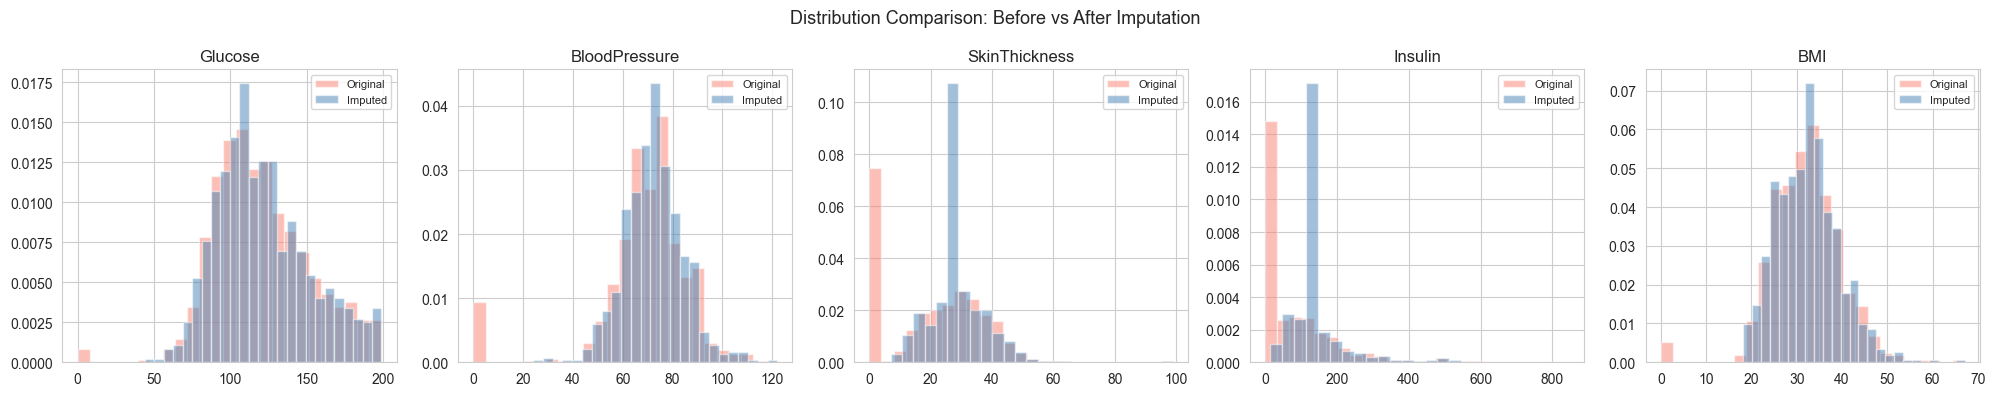

In [ ]:
# Compare distributions before and after imputation
fig, axes = plt.subplots(1, len(zero_invalid_cols), figsize=(20, 4))

for i, col in enumerate(zero_invalid_cols):
    axes[i].hist(df[col], bins=25, alpha=0.5, color="salmon", label="Original", density=True)
    axes[i].hist(df_clean[col], bins=25, alpha=0.5, color="steelblue", label="Imputed", density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle("Distribution Comparison: Before vs After Imputation", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Feature Engineering

In [ ]:
df_feat = create_features(df_clean)
print(f"Shape after feature engineering: {df_feat.shape}")
print(f"\nNew columns added: {set(df_feat.columns) - set(df_clean.columns)}")
df_feat.head()


Shape after feature engineering: (768, 14)

New columns added: {'BP_Category', 'Glucose_Category', 'AgeGroup', 'Insulin_Category', 'BMI_Category'}


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,AgeGroup,Glucose_Category,Insulin_Category,BP_Category
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Obese,40s,Diabetes,Normal,Normal
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Overweight,30s,Normal,Normal,Normal
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Normal,30s,Diabetes,Normal,Normal
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,20s,Normal,Normal,Normal
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,30s,Diabetes,High,Normal


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_72144/2041675280.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_rate = df_feat.groupby("BMI_Category")["Outcome"].mean() * 100
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_72144/2041675280.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  glucose_rate = df_feat.groupby("Glucose_Category")["Outcome"].mean() * 100
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_72144/2041675280.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fa

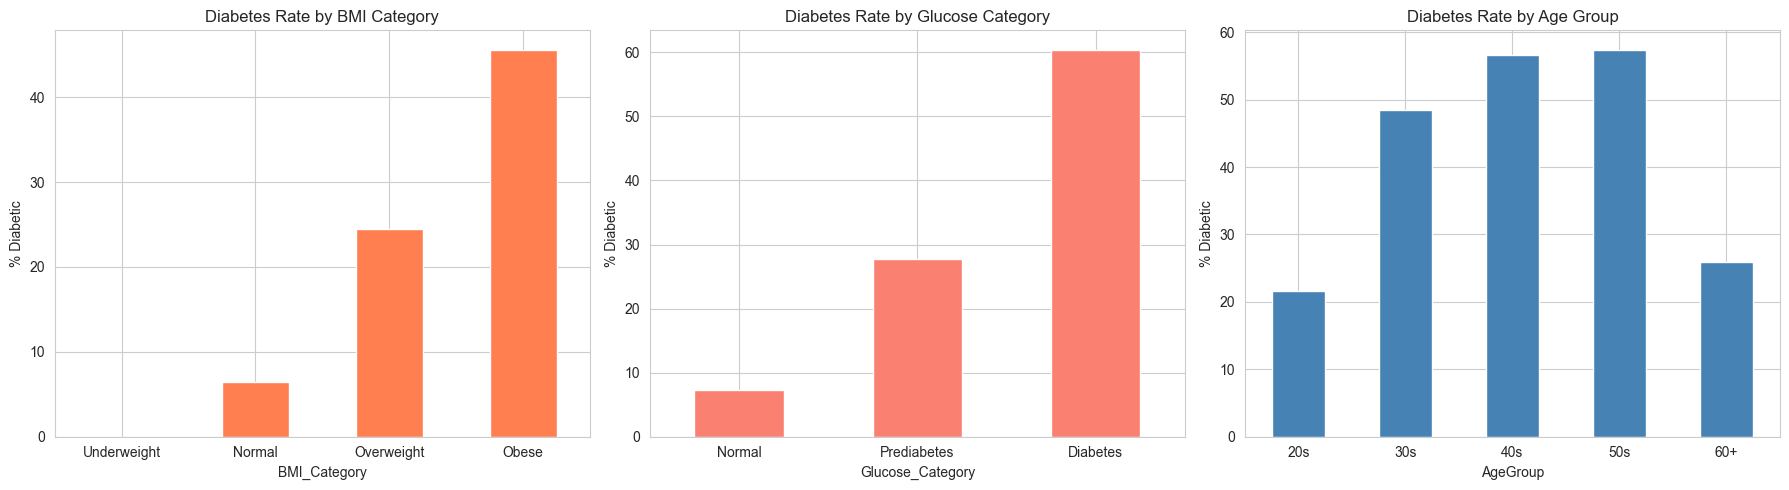

In [ ]:
# Diabetes rate by BMI category
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bmi_rate = df_feat.groupby("BMI_Category")["Outcome"].mean() * 100
bmi_rate.plot(kind="bar", color="coral", ax=axes[0])
axes[0].set_title("Diabetes Rate by BMI Category")
axes[0].set_ylabel("% Diabetic")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Diabetes rate by glucose category
glucose_rate = df_feat.groupby("Glucose_Category")["Outcome"].mean() * 100
glucose_rate.plot(kind="bar", color="salmon", ax=axes[1])
axes[1].set_title("Diabetes Rate by Glucose Category")
axes[1].set_ylabel("% Diabetic")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Diabetes rate by age group
age_rate = df_feat.groupby("AgeGroup")["Outcome"].mean() * 100
age_rate.plot(kind="bar", color="steelblue", ax=axes[2])
axes[2].set_title("Diabetes Rate by Age Group")
axes[2].set_ylabel("% Diabetic")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# Summary of diabetes rates by category
print("Diabetes rate by BMI Category:")
for cat in bmi_rate.index:
    n = (df_feat["BMI_Category"] == cat).sum()
    print(f"  {str(cat):15s}: {bmi_rate[cat]:.1f}% (n={n})")

print("\nDiabetes rate by Glucose Category:")
for cat in glucose_rate.index:
    n = (df_feat["Glucose_Category"] == cat).sum()
    print(f"  {str(cat):15s}: {glucose_rate[cat]:.1f}% (n={n})")


Diabetes rate by BMI Category:
  Underweight    : 0.0% (n=4)
  Normal         : 6.5% (n=108)
  Overweight     : 24.4% (n=180)
  Obese          : 45.6% (n=476)

Diabetes rate by Glucose Category:
  Normal         : 7.3% (n=192)
  Prediabetes    : 27.8% (n=288)
  Diabetes       : 60.4% (n=288)


## 5. Encode Categorical Features

In [ ]:
categorical_cols = ["BMI_Category", "AgeGroup", "Glucose_Category", "Insulin_Category", "BP_Category"]

df_encoded = pd.get_dummies(df_feat, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nColumns ({len(df_encoded.columns)}):")
for col in df_encoded.columns:
    print(f"  - {col} ({df_encoded[col].dtype})")


Shape after encoding: (768, 22)

Columns (22):
  - Pregnancies (int64)
  - Glucose (float64)
  - BloodPressure (float64)
  - SkinThickness (float64)
  - Insulin (float64)
  - BMI (float64)
  - DiabetesPedigreeFunction (float64)
  - Age (int64)
  - Outcome (int64)
  - BMI_Category_Normal (bool)
  - BMI_Category_Overweight (bool)
  - BMI_Category_Obese (bool)
  - AgeGroup_30s (bool)
  - AgeGroup_40s (bool)
  - AgeGroup_50s (bool)
  - AgeGroup_60+ (bool)
  - Glucose_Category_Prediabetes (bool)
  - Glucose_Category_Diabetes (bool)
  - Insulin_Category_Normal (bool)
  - Insulin_Category_High (bool)
  - BP_Category_High_Stage1 (bool)
  - BP_Category_High_Stage2 (bool)


In [ ]:
# Verify no missing values
print(f"Missing values: {df_encoded.isnull().sum().sum()}")
print(f"Final shape: {df_encoded.shape}")
df_encoded.head()


Missing values: 0
Final shape: (768, 22)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category_Normal,...,AgeGroup_30s,AgeGroup_40s,AgeGroup_50s,AgeGroup_60+,Glucose_Category_Prediabetes,Glucose_Category_Diabetes,Insulin_Category_Normal,Insulin_Category_High,BP_Category_High_Stage1,BP_Category_High_Stage2
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,False,...,False,True,False,False,False,True,True,False,False,False
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,False,...,True,False,False,False,False,False,True,False,False,False
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,True,...,True,False,False,False,False,True,True,False,False,False
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,False,...,False,False,False,False,False,False,True,False,False,False
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,False,...,True,False,False,False,False,True,False,True,False,False


## 6. Save Cleaned Dataset

In [ ]:
df_encoded.to_csv("data/diabetes_cleaned.csv", index=False)
print("Saved cleaned dataset to data/diabetes_cleaned.csv")
print(f"  Rows   : {df_encoded.shape[0]}")
print(f"  Columns: {df_encoded.shape[1]}")


Saved cleaned dataset to data/diabetes_cleaned.csv
  Rows   : 768
  Columns: 22


## Summary

| Step | Action | Details |
|------|--------|---------|
| 1 | Replace invalid zeros | 5 columns had 0s representing missing data |
| 2 | Median imputation | Robust to outliers in skewed features |
| 3 | Feature engineering | Created BMI_Category, AgeGroup, Glucose_Category, Insulin_Category, BP_Category |
| 4 | One-hot encoding | Encoded all categorical features (drop_first=True) |
| 5 | Save | Exported clean dataset for model building |